# STOCK PRICE PREDICTION PROJECT

In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 3.4 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.1 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
stock = "AAPL"

data = yf.download(
    stock,
    start="2020-01-01",
    end="2025-01-01"
)

print("First 5 Rows of Dataset:")
print(data.head())


[*********************100%***********************]  1 of 1 completed

First 5 Rows of Dataset:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267914  72.306483  70.568488  70.819186  118387200
2020-01-07  71.928062  72.533103  71.708703  72.277586  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


In [5]:
data["MA10"] = data["Close"].rolling(window=10).mean()

In [6]:
data["MA50"] = data["Close"].rolling(window=50).mean()

In [7]:
data["Daily_Return"] = data["Close"].pct_change()

# Target Variable (Next Day Closing Price)
data["Target"] = data["Close"].shift(-1)

# Remove missing values
data.dropna(inplace=True)

print("\nDataset After Feature Engineering:")
print(data.head())


Dataset After Feature Engineering:
Price           Close       High        Low       Open     Volume       MA10  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL              
Date                                                                           
2020-03-13  67.164749  67.635923  61.119268  64.004286  370732000  68.282520   
2020-03-16  58.524208  62.600432  57.990213  58.461383  322423600  66.914917   
2020-03-17  61.097523  62.245242  57.603611  59.804823  324056000  66.033948   
2020-03-18  59.601871  60.406486  57.294343  57.934654  300233600  64.679153   
2020-03-19  59.145191  61.092695  58.620863  59.775835  271857200  63.515965   

Price            MA50 Daily_Return     Target  
Ticker                                         
Date                                           
2020-03-13  73.801325     0.119808  58.524208  
2020-03-16  73.523799    -0.128647  61.097523  
2020-03-17  73.311816     0.043970  59.601871  
2020-03-18  73.058496    -0.024480 

In [8]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "MA10",
    "MA50",
    "Daily_Return"
]

X = data[features]

y = data["Target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


In [11]:
predictions = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance")
print("----------------------------")
print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))



Model Performance
----------------------------
Mean Absolute Error: 2.23
R2 Score: 0.99


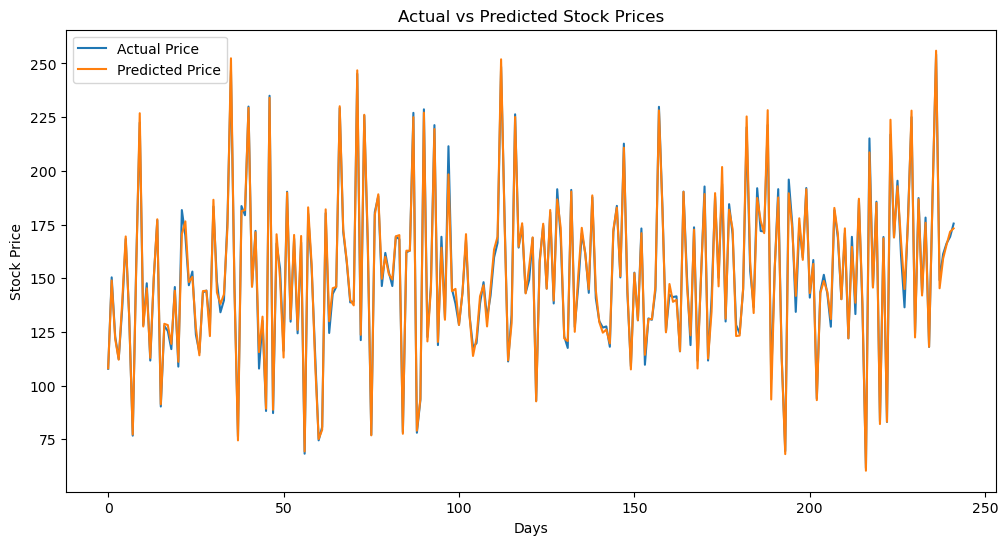

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

In [15]:
latest_data = X.tail(1)

next_day_prediction = model.predict(latest_data)

print("\nPredicted Next Day Closing Price:")
print("$", round(next_day_prediction[0], 2))


Predicted Next Day Closing Price:
$ 250.78


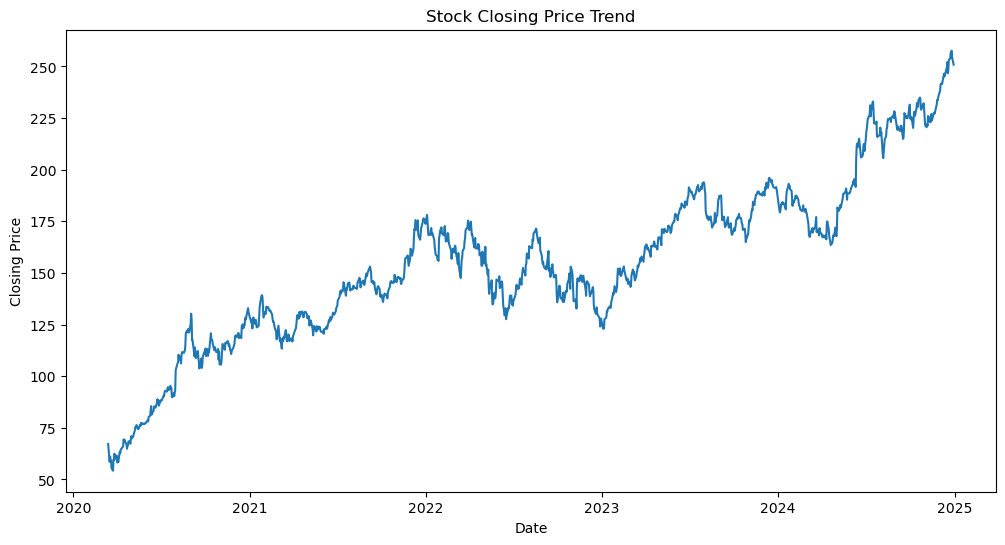

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(data["Close"])

plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()


In [17]:
data.to_csv("stock_data.csv")

print("\nDataset saved as stock_data.csv")


Dataset saved as stock_data.csv


In [18]:
print("\nStock Price Prediction Project Completed Successfully!")


Stock Price Prediction Project Completed Successfully!
